In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Checking Files are present or not 

In [2]:
# Checking files are present or not
main_folder = os.listdir("Dataset")
main_path = "Dataset"
flag = True
missing_files_path = []
for i in main_folder:
    under_path_name = f"{main_path}/{i}"
    sub_folder = os.listdir(f"{under_path_name}")
    for j in sub_folder:
        under_path_name_Ei = f"{under_path_name}/{j}"
        E_folder = os.listdir(f"{under_path_name_Ei}")
        for k in E_folder:
            file_path = under_path_name_Ei+"/"+k
            if(os.path.exists(f"{file_path}")==False):
                flag = False
                missing_files_path.append(file_path)
                

if flag == False:
    print("There is some file missing.")
    print("List of missing files:")
    for missing_file in missing_files_path:
        print(missing_file)
else:
    print("All files are present in every folder.")
        

All files are present in every folder.


In [3]:
#Checking the columns with nan values only, if they are present then drop it 
main_folder = os.listdir("Dataset")
main_path = "Dataset"
flag = True
missing_files_path = []
for i in main_folder:
    under_path_name = os.path.join(main_path,i)
    sub_folder = os.listdir(f"{under_path_name}")
    for j in sub_folder:
        under_path_name_Ei = os.path.join(under_path_name,j)
        E_folder = os.listdir(f"{under_path_name_Ei}")
        for k in E_folder:
            file_path = os.path.join(under_path_name_Ei,k,"Copy of target.csv")
            if(os.path.exists(f"{file_path}")==False):
                flag = False
                missing_files_path.append(file_path)
            else:
                try:
                    df = pd.read_csv(file_path)
                    new_file = "new_file"
                    new_file_path = os.path.join(under_path_name_Ei,k,"new_file.csv")
                    new_file = df.iloc[:,89:-1]
                    nan_columns = new_file.columns[new_file.isna().all()].tolist()
                    
                    # Print NaN column names if any
                    if nan_columns:
                        print(f"Columns with all NaN values in file {file_path}: {nan_columns}")
                    
                    # Drop columns with only NaN values
                    new_file = new_file.dropna(axis=1, how='all')
                    new_file.to_csv(new_file_path,index = False)
                except Exception as e:
                    print(f"Error Preprocessing file {file_path}:",e)
        

Columns with all NaN values in file Dataset\AMN\Control\E2\Copy of target.csv: ['t442']
Columns with all NaN values in file Dataset\AMN\Control\E3\Copy of target.csv: ['t441', 't442']
Columns with all NaN values in file Dataset\AMN\Main\E1\Copy of target.csv: ['t489', 't490', 't491', 't492', 't493', 't494', 't495', 't496']
Columns with all NaN values in file Dataset\AMN\Main\E3\Copy of target.csv: ['t527', 't528', 't529', 't530', 't531', 't532', 't533', 't534', 't535', 't536', 't537', 't538', 't539', 't540', 't541', 't542', 't543', 't544', 't545', 't546', 't547', 't548', 't549', 't550', 't551', 't552', 't553', 't554', 't555', 't556', 't557', 't558', 't559', 't560', 't561', 't562', 't563', 't564', 't565', 't566', 't567', 't568']
Columns with all NaN values in file Dataset\ARJ\Control\E1\Copy of target.csv: ['t467', 't468', 't469', 't470', 't471', 't472', 't473', 't474', 't475', 't476', 't477', 't478', 't479', 't480', 't481', 't482', 't483', 't484', 't485', 't486', 't487', 't488', 't489'

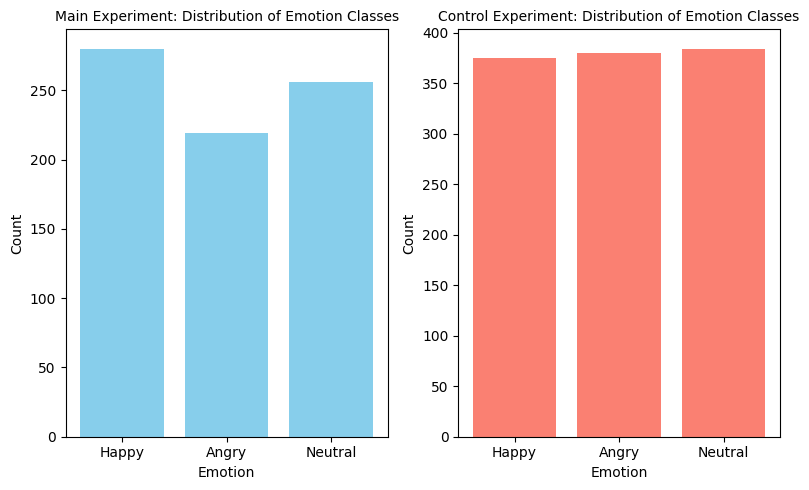

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def check_for_class_count(root_folder):
    main = [0, 0, 0]
    control = [0, 0, 0]

    # List all subfolders in the root data folder
    for subfolder in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder)
        for experiment in ['Main', 'Control']:
            condition_path = os.path.join(subfolder_path, experiment)
            ind = 0
            for block in ['E1', 'E2', 'E3']:
                exp_path = os.path.join(condition_path, block)
                target_file = os.path.join(exp_path, 'Copy of target.csv')

                if os.path.exists(target_file):
                    try:
                        data_file = pd.read_csv(target_file)
                        row_count = data_file.shape[0]

                        # Add row counts to the respective lists for Main and Control
                        if experiment == "Main":
                            main[ind] += row_count
                        else:
                            control[ind] += row_count
                    except Exception as e:
                        print(f"Error reading file {target_file}: {e}")
                ind += 1

    # Prepare data for bar charts
    emotions = ['Happy', 'Angry', 'Neutral']
    data_main = {
        'Emotion': emotions,
        'Count': main
    }
    data_control = {
        'Emotion': emotions,
        'Count': control
    }
    df_main = pd.DataFrame(data_main)
    df_control = pd.DataFrame(data_control)

    # Plot bar charts for main and control experiments
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))

    ax1.bar(df_main['Emotion'], df_main['Count'], color='skyblue')
    ax1.set_title("Main Experiment: Distribution of Emotion Classes", fontsize=10)
    ax1.set_xlabel("Emotion")
    ax1.set_ylabel("Count")

    ax2.bar(df_control['Emotion'], df_control['Count'], color='salmon')
    ax2.set_title("Control Experiment: Distribution of Emotion Classes", fontsize=10)
    ax2.set_xlabel("Emotion")
    ax2.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Example usage
root_folder = "Dataset"
check_for_class_count(root_folder)


### Data Processing Summary for Control and Main Conditions

After preprocessing all the data, I created three separate CSV files to consolidate the average pupil dilation values for all individuals across each experimental stage in both the control and main conditions.

#### Control Condition CSV Files
1. **Control_E1_file_for_every_individual.csv**: Contains the average pupil dilation values for all individuals in the E1 stage.
2. **Control_E2_file_for_every_individual.csv**: Contains the average pupil dilation values for all individuals in the E2 stage.
3. **Control_E3_file_for_every_individual.csv**: Contains the average pupil dilation values for all individuals in the E3 stage.

#### Main Condition CSV Files
Similarly, corresponding CSV files were generated for the main condition to represent individuals' pupil dilation responses across emotions:
1. **Main_E1_file_for_every_individual.csv**: Contains the average pupil dilation values for all individuals in the E1 stage.
2. **Main_E2_file_for_every_individual.csv**: Contains the average pupil dilation values for all individuals in the E2 stage.
3. **Main_E3_file_for_every_individual.csv**: Contains the average pupil dilation values for all individuals in the E3 stage.

These files provide a consolidated view of how individuals' pupil dilation responses vary in the main experiment compared to control tasks.


In [5]:


# Path to the main "Dataset" folder

"""
FOR CONTROL
"""

main_path = "Dataset"
e1_array=[]
e2_array=[]
e3_array=[]
headers=[
    [0,[]],
    [0,[]],
    [0,[]]
]
main_folder = os.listdir(main_path)
for i in main_folder:
    under_path_name = os.path.join(main_path, i)
    sub_folder = os.listdir(under_path_name)
    
    under_path_name_Ei = os.path.join(under_path_name, "Control")
    
    if os.path.isdir(under_path_name_Ei):
        E_folder = os.listdir(under_path_name_Ei)
        
        for k in E_folder:
            file_path = os.path.join(under_path_name_Ei, k, "new_file.csv")
            
            try:
                if os.path.isfile(file_path):
                    df = pd.read_csv(file_path)
                    mean = df.select_dtypes(include='number').iloc[:, :].mean(skipna=True)
                    mean=pd.DataFrame(mean).T
                    if(k=="E1"):
                        e1_array.append(mean.values.flatten())
                        if(len(mean.columns) > headers[0][0]):
                            headers[0][0]=len(mean.columns)
                            headers[0][1]=mean.columns
                    if(k=="E2"):
                        e2_array.append(mean.values.flatten())
                        if(len(mean.columns) > headers[1][0]):
                            headers[1][0]=len(mean.columns)
                            headers[1][1]=mean.columns
                       
                    if(k=="E3"):
                        e3_array.append(mean.values.flatten())
                        if(len(mean.columns) > headers[2][0]):
                            headers[2][0]=len(mean.columns)
                            headers[2][1]=mean.columns
                        
                else:
                    missing_files_path.append(file_path)
            except Exception as e:
                print(f"Error processing file {file_path}: {e}")

data=pd.DataFrame(e1_array)
data.columns=headers[0][1]
pd.DataFrame.to_csv(data,"Control_E1_file_for_every_individual.csv",index=False)
    
data=pd.DataFrame(e2_array)
data.columns=headers[1][1]
pd.DataFrame.to_csv(data,"Control_E2_file_for_every_individual.csv",index=False)

data=pd.DataFrame(e3_array)
data.columns=headers[2][1]
pd.DataFrame.to_csv(data,"Control_E3_file_for_every_individual.csv",index=False)


In [6]:
# Path to the main "Dataset" folder

"""
FOR MAIN
"""

main_path = "Dataset"
e1_array=[]
e2_array=[]
e3_array=[]
headers=[
    [0,[]],
    [0,[]],
    [0,[]]
]
main_folder = os.listdir(main_path)
for i in main_folder:
    under_path_name = os.path.join(main_path, i)
    sub_folder = os.listdir(under_path_name)
    
    under_path_name_Ei = os.path.join(under_path_name, "Main")
    
    if os.path.isdir(under_path_name_Ei):
        E_folder = os.listdir(under_path_name_Ei)
        
        for k in E_folder:
            file_path = os.path.join(under_path_name_Ei, k, "new_file.csv")
            
            try:
                if os.path.isfile(file_path):
                    df = pd.read_csv(file_path)
                    mean = df.select_dtypes(include='number').iloc[:, :].mean(skipna=True)
                    mean=pd.DataFrame(mean).T
                    if(k=="E1"):
                        e1_array.append(mean.values.flatten())
                        if(len(mean.columns) > headers[0][0]):
                            headers[0][0]=len(mean.columns)
                            headers[0][1]=mean.columns
                    if(k=="E2"):
                        e2_array.append(mean.values.flatten())
                        if(len(mean.columns) > headers[1][0]):
                            headers[1][0]=len(mean.columns)
                            headers[1][1]=mean.columns
                       
                    if(k=="E3"):
                        e3_array.append(mean.values.flatten())
                        if(len(mean.columns) > headers[2][0]):
                            headers[2][0]=len(mean.columns)
                            headers[2][1]=mean.columns
                        
                else:
                    missing_files_path.append(file_path)
            except Exception as e:
                print(f"Error processing file {file_path}: {e}")

data=pd.DataFrame(e1_array)
data.columns=headers[0][1]
pd.DataFrame.to_csv(data,"Main_E1_file_for_every_individual.csv",index=False)
    
data=pd.DataFrame(e2_array)
data.columns=headers[1][1]
pd.DataFrame.to_csv(data,"Main_E2_file_for_every_individual.csv",index=False)

data=pd.DataFrame(e3_array)
data.columns=headers[2][1]
pd.DataFrame.to_csv(data,"Main_E3_file_for_every_individual.csv",index=False)


### Data Consolidation and Median Calculation
From each of these CSV files for both the main and control conditions, the  average of the pupil dilation values was calculated. These mean values were stored in arrays, which were then saved in an arrays for further analysis.



In [7]:
# here will do the median averages for Control_E1, Control_E2, Control_E3 and the median averages for Main_E1, Main_E2 and Main_E3
files = [
    ("Control_E1_file_for_every_individual.csv", "Control_E1_average"),
    ("Control_E2_file_for_every_individual.csv", "Control_E2_average"),
    ("Control_E3_file_for_every_individual.csv", "Control_E3_average")
]


median_averages = {}

Control_E1_rows = df.iloc[0].values
Control_E2_rows = df.iloc[0].values
Control_E3_rows = df.iloc[0].values
max_length_array = max([Control_E1_rows, Control_E2_rows, Control_E3_rows], key=len)

for file_name, avg_name in files:
    data = pd.read_csv(file_name)
    median_averages[avg_name] = data.mean(axis=0).values
    print(f"{avg_name}:", median_averages[avg_name])

data=pd.DataFrame(median_averages["Control_E1_average"]).T
pd.DataFrame.to_csv(data,"Control_E1_Avg.csv",index=False)

data=pd.DataFrame(median_averages["Control_E2_average"]).T
pd.DataFrame.to_csv(data,"Control_E2_Avg.csv",index=False)

data=pd.DataFrame(median_averages["Control_E3_average"]).T
pd.DataFrame.to_csv(data,"Control_E3_Avg.csv",index=False)

Control_E1_average: [3.53452998 3.53474375 3.53478647 3.53252485 3.53061399 3.52783372
 3.52783307 3.53366327 3.53259512 3.53301359 3.53244413 3.53296634
 3.53336362 3.5344759  3.53469673 3.53545206 3.53743165 3.53849917
 3.53885444 3.54048464 3.54141085 3.54322949 3.54466913 3.54566379
 3.5464199  3.54918565 3.54981939 3.55156661 3.55266898 3.55408694
 3.55616978 3.558207   3.55948256 3.55989667 3.56206066 3.56460322
 3.56420806 3.5654167  3.56701255 3.56749388 3.56872907 3.56978387
 3.570705   3.5705963  3.57076225 3.56916734 3.56581499 3.55903266
 3.55210258 3.54382836 3.53344591 3.52060054 3.5069908  3.49231424
 3.47632529 3.45773495 3.43773121 3.41861321 3.3976178  3.37810997
 3.35809135 3.33742978 3.31707647 3.29811762 3.2784402  3.26028276
 3.24134079 3.2264051  3.20923683 3.19319102 3.18002796 3.16735331
 3.15330559 3.13845778 3.1251071  3.11404342 3.1044907  3.09735035
 3.08780821 3.07942553 3.07304389 3.06726458 3.06041865 3.05536416
 3.05138799 3.04653282 3.04151065 3.040124

In [8]:
main_files = [
    ("Main_E1_file_for_every_individual.csv", "Main_E1_average"),
    ("Main_E2_file_for_every_individual.csv", "Main_E2_average"),
    ("Main_E3_file_for_every_individual.csv", "Main_E3_average")
]
Main_E1_rows = df.iloc[0].values
Main_E2_rows = df.iloc[0].values
Main_E3_rows = df.iloc[0].values
max_length_array_main = max([Main_E1_rows, Main_E2_rows, Main_E3_rows ], key=len)
main_median_averages = {}
for file_name, avg_name in main_files:
    data = pd.read_csv(file_name)
    main_median_averages[avg_name] = data.mean(axis=0).values
    print(f"{avg_name}:", main_median_averages[avg_name])

data=pd.DataFrame(main_median_averages["Main_E1_average"]).T
pd.DataFrame.to_csv(data,"Main_E1_Avg.csv",index=False)

data=pd.DataFrame(main_median_averages["Main_E2_average"]).T
pd.DataFrame.to_csv(data,"Main_E2_Avg.csv",index=False)

data=pd.DataFrame(main_median_averages["Main_E3_average"]).T
pd.DataFrame.to_csv(data,"Main_E3_Avg.csv",index=False)

Main_E1_average: [3.82515923 3.82359573 3.82353853 3.82192289 3.82165822 3.82001753
 3.82035573 3.82143689 3.81935529 3.82248341 3.81894439 3.82130472
 3.82058597 3.82010616 3.82151383 3.8230801  3.82358675 3.82346447
 3.82534587 3.8274574  3.82862183 3.82933182 3.83023669 3.83103993
 3.83455754 3.83664531 3.83740781 3.83931631 3.84080216 3.84148787
 3.84349125 3.84449716 3.8459002  3.84685171 3.8484032  3.850909
 3.84919753 3.85086518 3.85143057 3.85245516 3.85403519 3.85405342
 3.85481902 3.85634603 3.85694271 3.85580072 3.85372038 3.85078558
 3.84472633 3.83845121 3.83023738 3.81966461 3.80660929 3.79095695
 3.77410356 3.7551289  3.73499954 3.71497572 3.69383858 3.67142257
 3.64786868 3.62634556 3.60413309 3.58243961 3.56106811 3.5412205
 3.52005836 3.50048234 3.48243117 3.46374036 3.44404548 3.42617199
 3.41044195 3.39681175 3.38294112 3.3697496  3.35740837 3.3463494
 3.3359313  3.32514713 3.31568901 3.30633874 3.29885573 3.29254953
 3.28636774 3.28033186 3.275468   3.27163942 3.26

### Visualization of Pupil Dilation Trends by Emotion
A graph was plotted to show the trends in pupil dilation across emotions for each stage. The resulting mean values were used to observe any distinct trends by emotion.

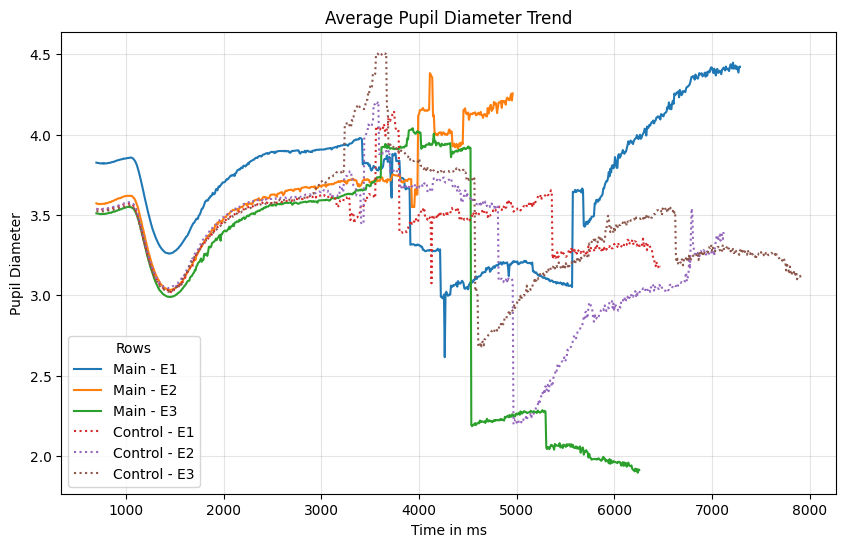

{'Control - E1': array([3.53452998, 3.53474375, 3.53478647, 3.53252485, 3.53061399,
       3.52783372, 3.52783307, 3.53366327, 3.53259512, 3.53301359,
       3.53244413, 3.53296634, 3.53336362, 3.5344759 , 3.53469673,
       3.53545206, 3.53743165, 3.53849917, 3.53885444, 3.54048464,
       3.54141085, 3.54322949, 3.54466913, 3.54566379, 3.5464199 ,
       3.54918565, 3.54981939, 3.55156661, 3.55266898, 3.55408694,
       3.55616978, 3.558207  , 3.55948256, 3.55989667, 3.56206066,
       3.56460322, 3.56420806, 3.5654167 , 3.56701255, 3.56749388,
       3.56872907, 3.56978387, 3.570705  , 3.5705963 , 3.57076225,
       3.56916734, 3.56581499, 3.55903266, 3.55210258, 3.54382836,
       3.53344591, 3.52060054, 3.5069908 , 3.49231424, 3.47632529,
       3.45773495, 3.43773121, 3.41861321, 3.3976178 , 3.37810997,
       3.35809135, 3.33742978, 3.31707647, 3.29811762, 3.2784402 ,
       3.26028276, 3.24134079, 3.2264051 , 3.20923683, 3.19319102,
       3.18002796, 3.16735331, 3.15330559, 3.

In [16]:
# Control and Main files for E1, E2, and E3 datasets
control_files = [
    ("Control_E1_file_for_every_individual.csv", "Control - E1"),
    ("Control_E2_file_for_every_individual.csv", "Control - E2"),
    ("Control_E3_file_for_every_individual.csv", "Control - E3")
]

main_files = [
    ("Main_E1_file_for_every_individual.csv", "Main - E1"),
    ("Main_E2_file_for_every_individual.csv", "Main - E2"),
    ("Main_E3_file_for_every_individual.csv", "Main - E3")
]
control_averages = {}
main_averages = {}

# Calculating medians for Control files
for file_name, avg_name in control_files:
    data = pd.read_csv(file_name)
    control_averages[avg_name] = data.mean(axis=0).values

# Calculating medians for Main files
for file_name, avg_name in main_files:
    data = pd.read_csv(file_name)
    main_averages[avg_name] = data.mean(axis=0).values

# Plotting
plt.figure(figsize=(10, 6))

""" max_len_main=0
for avg_name, median_values in main_averages.items():
    max_len_main=max(max_len_main,len(median_values))
print(max_len_main)
time=[] """

# Plot Main data with solid lines
for avg_name, mean_values in main_averages.items():
    time=[]
    for i in range(len(mean_values)):
        time.append(696+(i)*8)
    plt.plot(time,mean_values, label=f"{avg_name}", linestyle='-', linewidth=1.5)

""" max_len_ctrl=0
for avg_name, median_values in control_averages.items():
    max_len_ctrl=max(max_len_ctrl,len(median_values))
print(max_len_ctrl)
c_time=[] """

# Plot Control data with dotted lines
for avg_name, median_values in control_averages.items():
    time=[]
    for i in range(len(median_values)):
        time.append(696+(i)*8)
    plt.plot(time,median_values, label=f"{avg_name}", linestyle=':', linewidth=1.5)

# Labels, title, and grid
plt.xlabel("Time in ms")
plt.ylabel("Pupil Diameter")
plt.title("Average Pupil Diameter Trend")
plt.grid(True)
plt.legend(title="Rows")
# Show plot
plt.show()
print(control_averages)
print(main_averages)


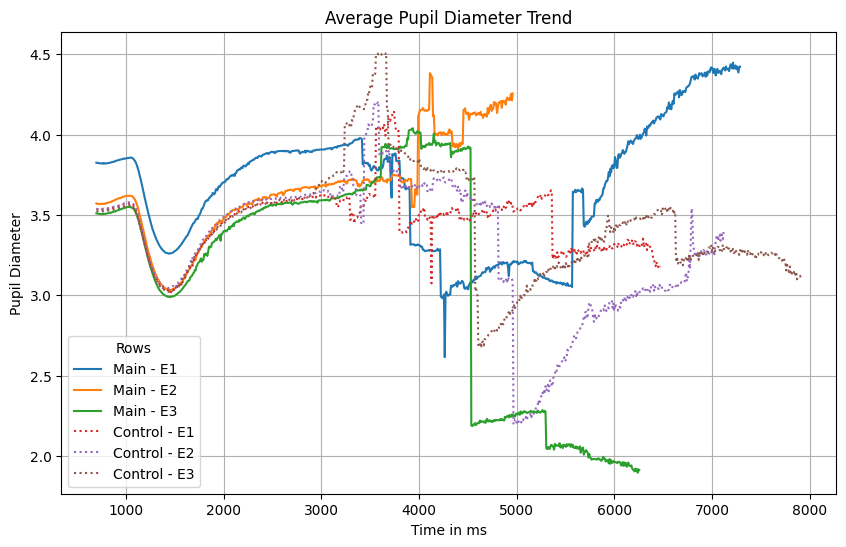

CSV files 'control_averages.csv' and 'main_averages.csv' have been created successfully.


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# # Control and Main files for E1, E2, and E3 datasets
# control_files = [
#     ("Control_E1_file_for_every_individual.csv", "Control - E1"),
#     ("Control_E2_file_for_every_individual.csv", "Control - E2"),
#     ("Control_E3_file_for_every_individual.csv", "Control - E3")
# ]

# main_files = [
#     ("Main_E1_file_for_every_individual.csv", "Main - E1"),
#     ("Main_E2_file_for_every_individual.csv", "Main - E2"),
#     ("Main_E3_file_for_every_individual.csv", "Main - E3")
# ]

# control_averages = {}
# main_averages = {}

# # Calculating averages for Control files
# for file_name, avg_name in control_files:
#     data = pd.read_csv(file_name)
#     control_averages[avg_name] = data.mean(axis=0).values

# # Calculating averages for Main files
# for file_name, avg_name in main_files:
#     data = pd.read_csv(file_name)
#     main_averages[avg_name] = data.mean(axis=0).values

# # Find the maximum length of all the arrays (control and main)
# max_len = max(
#     [len(values) for values in control_averages.values()] + 
#     [len(values) for values in main_averages.values()]
# )

# # Padding the arrays to ensure they all have the same length (max_len)
# for avg_name, values in control_averages.items():
#     if len(values) < max_len:
#         control_averages[avg_name] = np.pad(values, (0, max_len - len(values)), constant_values=np.nan)

# for avg_name, values in main_averages.items():
#     if len(values) < max_len:
#         main_averages[avg_name] = np.pad(values, (0, max_len - len(values)), constant_values=np.nan)

# # Convert control averages to DataFrame and save to CSV
# control_df = pd.DataFrame(control_averages)
# control_df.to_csv("control_averages.csv", index=False)

# # Convert main averages to DataFrame and save to CSV
# main_df = pd.DataFrame(main_averages)
# main_df.to_csv("main_averages.csv", index=False)

# # Plotting
# plt.figure(figsize=(10, 6))

# # Plot Main data with solid lines
# for avg_name, mean_values in main_averages.items():
#     time = [696 + (i) * 8 for i in range(len(mean_values))]
#     plt.plot(time, mean_values, label=f"{avg_name}", linestyle='-', linewidth=1.5)

# # Plot Control data with dotted lines
# for avg_name, median_values in control_averages.items():
#     time = [696 + (i) * 8 for i in range(len(median_values))]
#     plt.plot(time, median_values, label=f"{avg_name}", linestyle=':', linewidth=1.5)

# # Labels, title, and grid
# plt.xlabel("Time in ms")
# plt.ylabel("Pupil Diameter")
# plt.title("Average Pupil Diameter Trend")
# plt.grid(True)
# plt.legend(title="Rows")

# # Show plot
# plt.show()

# print("CSV files 'control_averages.csv' and 'main_averages.csv' have been created successfully.")


In [17]:
main_path = "Dataset"
missing_files_path = []
main_array = []

main_folder = os.listdir(main_path)
for i in main_folder:
    under_path_name = os.path.join(main_path, i)
    
    under_path_name_Ei = os.path.join(under_path_name, "Control")
    
    if os.path.isdir(under_path_name_Ei):
        E_folder = os.listdir(under_path_name_Ei)
        median_dict = {}
        
        for k in E_folder:
            file_path = os.path.join(under_path_name_Ei, k, "new_file.csv")
            
            try:
                if os.path.isfile(file_path):
                    df = pd.read_csv(file_path)
                    medians = df.select_dtypes(include='number').iloc[:, :-1].median()
                    medians_array = medians.to_numpy()
                    if k in median_dict:
                        median_dict[k].append(medians_array)
                    else:
                        median_dict[k] = [medians_array]
                else:
                    missing_files_path.append(file_path)
            except Exception as e:
                print(f"Error processing file {file_path}: {e}")
        main_array.append(median_dict)


grouped_medians = {"E1": [], "E2": [], "E3": []}


for data in main_array:
    for key in grouped_medians.keys():
        if key in data:
            grouped_medians[key].extend(data[key])

final_medians = {}
for key, medians_list in grouped_medians.items():
    if medians_list:
        median_df = pd.DataFrame(medians_list)
        final_medians[key] = median_df.median().to_numpy()

print("Final Medians by Group:", final_medians)
print("Missing Files:", missing_files_path)


Final Medians by Group: {'E1': array([3.7374847 , 3.73714295, 3.73722398, 3.7282155 , 3.72807888,
       3.72305833, 3.72630453, 3.72824052, 3.7126273 , 3.72788095,
       3.72284558, 3.72100825, 3.72349832, 3.72247035, 3.72691038,
       3.72434155, 3.73215265, 3.73408128, 3.7306312 , 3.73191205,
       3.73529423, 3.73662567, 3.73643005, 3.74081805, 3.74350928,
       3.74125745, 3.73826767, 3.75346122, 3.7554039 , 3.74734747,
       3.76439575, 3.75620152, 3.75826778, 3.7574776 , 3.7584625 ,
       3.75874538, 3.75523162, 3.75994355, 3.75983983, 3.76986587,
       3.76360847, 3.76838505, 3.766955  , 3.7708354 , 3.7656768 ,
       3.76341408, 3.76245792, 3.75800168, 3.7571409 , 3.7381525 ,
       3.7340721 , 3.70090425, 3.686757  , 3.65903545, 3.63310615,
       3.619331  , 3.59599625, 3.57055205, 3.5459509 , 3.52487708,
       3.5142844 , 3.49341805, 3.474412  , 3.4533261 , 3.4348998 ,
       3.424433  , 3.4067041 , 3.39430655, 3.37763205, 3.3620951 ,
       3.35074585, 3.34417035, 

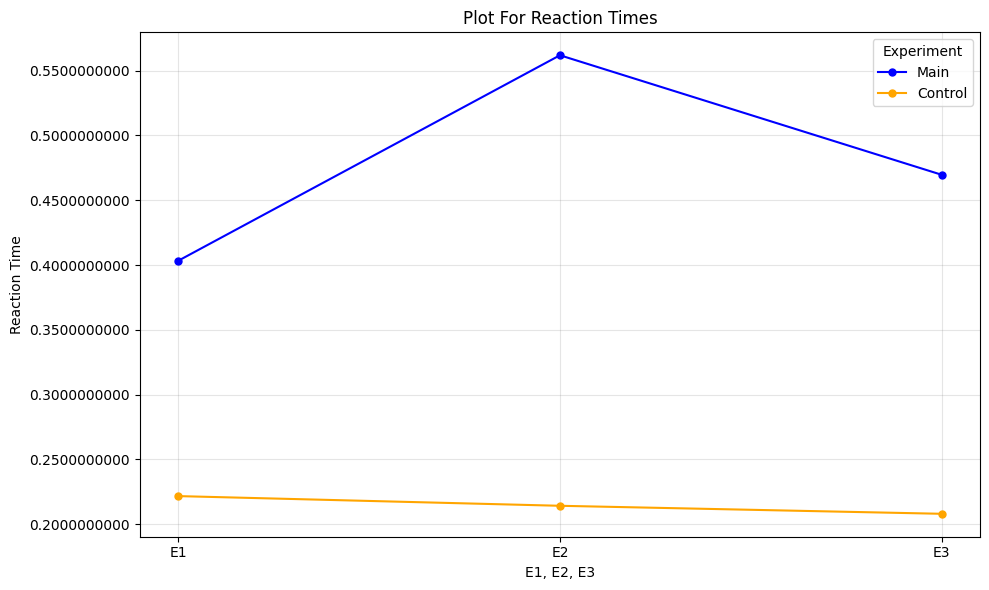


-------FOR MAIN EXPERIMENT-------
    Name       E1       E2       E3
AMN_Main 0.389359 0.516025 0.626478
ARJ_Main 0.524087 0.725061 0.672941
DIV_Main 0.323662 0.388816 0.394350
PAR_Main 0.417079 0.652743 0.475473
RAJ_Main 0.316535 0.478857 0.427256
RAM_Main 0.251681 0.487282 0.456187
ROR_Main 0.625007 0.618390 0.710602
SAR_Main 0.465004 0.762871 0.438117
SUK_Main 0.352999 0.607731 0.463735
SUY_Main 0.482513 0.467047 0.480087

Main Weighted Means:
E1   0.403219
E2   0.561878
E3   0.469604
dtype: float64

-------FOR Control EXPERIMENT-------
       Name       E1       E2       E3
AMN_Control 0.242446 0.259158 0.244703
ARJ_Control 0.267369 0.243242 0.261717
DIV_Control 0.163751 0.166953 0.160372
PAR_Control 0.316647 0.322229 0.313044
RAJ_Control 0.221147 0.187357 0.205404
RAM_Control 0.157675 0.184438 0.175991
ROR_Control 0.222134 0.210408 0.210561
SAR_Control 0.194430 0.217925 0.201062
SUK_Control 0.201880 0.199822 0.203356
SUY_Control 0.339502 0.308651 0.307491

Control Weighted Means

In [18]:


def process_type(experiment_type):
    main_path = "Dataset"
    missing_files_path = []
    main_array = []
    main_folder = os.listdir(main_path)
    
    for i in main_folder:
        under_path_name = os.path.join(main_path, i)
        under_path_name_Ei = os.path.join(under_path_name, experiment_type)
        
        if os.path.isdir(under_path_name_Ei):
            weighted_array = [i]
            E_folder = os.listdir(under_path_name_Ei)
            
            for k in E_folder:
                file_path = os.path.join(under_path_name_Ei, k, "copy of target.csv")
                try:
                    if os.path.isfile(file_path):
                        df = pd.read_csv(file_path)
                        if 'response_time' not in df.columns:
                            print(f"'response_time' column not found in {file_path}")
                            continue
                        
                        value = df["response_time"]
                        weighted_mean = np.median(value)
                        weighted_array.append(weighted_mean)
                    else:
                        missing_files_path.append(file_path)
                except Exception as e:
                    print(f"Error processing file {file_path}: {e}")
            
            if len(weighted_array) > 1:
                main_array.append(weighted_array)
    
    df = pd.DataFrame(main_array, columns=['Name', 'E1', 'E2', 'E3'])
    df['Name'] = df['Name'] + f'_{experiment_type}'
    weighted_mean_final = df[['E1', 'E2', 'E3']].median()
    
    return df, weighted_mean_final
df_main, weighted_mean_final_main = process_type('Main')
df_control, weighted_mean_final_control = process_type('Control')

plt.figure(figsize=(10, 6))
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.alpha'] = 0.2
main_values = weighted_mean_final_main.values
control_values = weighted_mean_final_control.values
plt.plot(['E1', 'E2', 'E3'], main_values, 
         color='blue', marker='.', linestyle='-', 
         label='Main', markersize=10, 
         markeredgecolor='blue', markerfacecolor='blue')

plt.plot(['E1', 'E2', 'E3'], control_values, 
         color='#FFA500', marker='.', linestyle='-', 
         label='Control', markersize=10,
         markeredgecolor='#FFA500', markerfacecolor='#FFA500')
plt.title('Plot For Reaction Times')
plt.xlabel('E1, E2, E3')
plt.ylabel('Reaction Time')
plt.grid(True, which='both', linestyle='-', alpha=0.2)
plt.legend(title='Experiment', loc='upper right')

# Set y-axis format to show full float numbers
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.10f'))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()

# Print results
pd.set_option('display.float_format', lambda x: '%.6f' % x)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\n-------FOR MAIN EXPERIMENT-------")
print(df_main.to_string(index=False))
print("\nMain Weighted Means:")
print(weighted_mean_final_main)

print("\n-------FOR Control EXPERIMENT-------")
print(df_control.to_string(index=False))
print("\nControl Weighted Means:")
print(weighted_mean_final_control)

- The standard deviation of pupil dilation was calculated for each block (E1, E2, E3) in both main and control experiments to gauge the variability in physiological responses

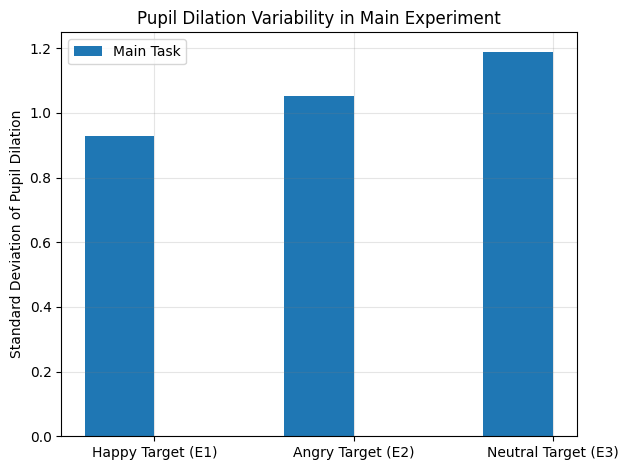

In [13]:
main_e1 = pd.read_csv('Main_E1_file_for_every_individual.csv')
main_e2 = pd.read_csv('Main_E2_file_for_every_individual.csv')
main_e3 = pd.read_csv('Main_E3_file_for_every_individual.csv')

main_std_e1 = main_e1.std(axis=0)
main_std_e2 = main_e2.std(axis=0)
main_std_e3 = main_e3.std(axis=0)

main_std = [main_std_e1.mean(), main_std_e2.mean(), main_std_e3.mean()]

labels = ['Happy Target (E1)', 'Angry Target (E2)', 'Neutral Target (E3)']
x = np.arange(len(labels))  
width = 0.35 

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, main_std, width, label='Main Task')


ax.set_ylabel('Standard Deviation of Pupil Dilation')
ax.set_title('Pupil Dilation Variability in Main Experiment')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.show()


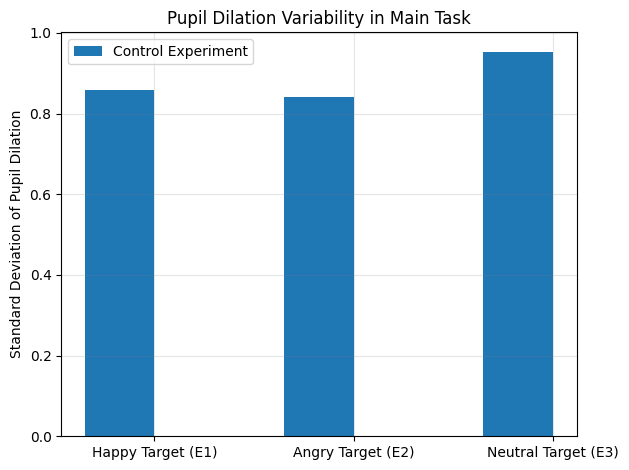

In [14]:
control_e1 = pd.read_csv('Control_E1_file_for_every_individual.csv')
control_e2 = pd.read_csv('Control_E2_file_for_every_individual.csv')
control_e3 = pd.read_csv('Control_E3_file_for_every_individual.csv')

control_std_e1 = control_e1.std(axis=0)
control_std_e2 = control_e2.std(axis=0)
control_std_e3 = control_e3.std(axis=0)

control_std = [control_std_e1.mean(), control_std_e2.mean(), control_std_e3.mean()]

labels = ['Happy Target (E1)', 'Angry Target (E2)', 'Neutral Target (E3)']
x = np.arange(len(labels))  
width = 0.35 

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, control_std, width, label='Control Experiment')


ax.set_ylabel('Standard Deviation of Pupil Dilation')
ax.set_title('Pupil Dilation Variability in Main Task')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.show()


- checking upto minimum number of column to which there is the pupil diameter(min of last column with data)
- upto maximum number of column to which there is pupil diameter in the column( max of last column with data)

In [ ]:
# import os
# import pandas as pd

# def check_for_last_col(root_folder):
#     main=[[10000,0],[10000,0],[10000,0]]
#     control=[[10000,0],[10000,0],[10000,0]]
#     e1=["","",""]
#     e2=["","",""]
#     e3=""

#     # List all subfolders in the root data folder
#     for subfolder in os.listdir(root_folder):
#         subfolder_path = os.path.join(root_folder, subfolder)
#         for experiment in ['Main', 'Control']:
#                 condition_path = os.path.join(subfolder_path, experiment)
#                 ind=0
#                 for block in ['E1', 'E2', 'E3']:
#                         exp_path = os.path.join(condition_path, block)
#                         target_file = os.path.join(exp_path, 'new_file.csv')
#                         data=pd.read_csv(target_file)
#                         col_count=len(data.columns)
#                         if(experiment=="Main"):
#                               # TEST FOR MIN
#                               if(col_count < main[ind][0]):
#                                     main[ind][0]=col_count
#                               # TEST FOR MAX
#                               elif(col_count > main[ind][1]):
#                                     main[ind][1]=col_count
#                                     e1[ind]=target_file
#                         else:
#                               # TEST FOR MIN
#                               if(col_count < control[ind][0]):
#                                     control[ind][0]=col_count
#                               # TEST FOR MAX
#                               elif(col_count > control[ind][1]):
#                                     control[ind][1]=col_count
#                                     e2[ind]=target_file
#                         ind+=1
    
#     datafarme={
#           "Main":main,
#           "Control":control
#     }
#     df=pd.DataFrame(datafarme)
#     df.index=["E1 (Min,Max)","E2 (Min,Max)","E3 (Min,Max)"]
#     print(df.T)   
#     print(e1,e2)
                              

# root_folder = "Dataset"
# check_for_last_col(root_folder)

        E1 (Min,Max) E2 (Min,Max) E3 (Min,Max)
Main      [341, 825]   [364, 534]   [365, 696]
Control   [324, 723]   [312, 804]   [318, 903]
['Dataset\\SUY\\Main\\E1\\new_file.csv', 'Dataset\\SUY\\Main\\E2\\new_file.csv', 'Dataset\\SUY\\Main\\E3\\new_file.csv'] ['Dataset\\SUY\\Control\\E1\\new_file.csv', 'Dataset\\SUY\\Control\\E2\\new_file.csv', 'Dataset\\SUY\\Control\\E3\\new_file.csv']
